Load and Stack Single fc.txt files into a numpy array of shape (n subjects, n nodes, n nodes), and verify matrix symmetry and ROI consistency

FC Matrix Information

*   Each subject has one .txt file

1. File format: Comma-delimited (",")

2. Matrix shape:96 × 96

This matches RM96 ROI atlas perfectly

3. Diagonal: The diagonal entries are NaN

This is common for FC exports (self-connections undefined)

4. Symmetry: The matrix is numerically symmetric

Maximum asymmetry ≈ 1e-14 (floating-point noise only)

5. Values: all off-diagonal values are finite

Magnitudes are consistent with correlation or Fisher-Z FC values










In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/Graph Theory Project/Functional Connectivity"
CN_W_DIR = "/content/drive/MyDrive/Graph Theory Project/Functional Connectivity/CN_W"
CN_M_DIR = "/content/drive/MyDrive/Graph Theory Project/Functional Connectivity/CN_M"
AD_W_DIR = "/content/drive/MyDrive/Graph Theory Project/Functional Connectivity/AD_W"
AD_M_DIR = "/content/drive/MyDrive/Graph Theory Project/Functional Connectivity/AD_M"



Mounted at /content/drive


In [ ]:
# ================================
# Import required libraries
# ================================

import os                 # for navigating folders and file paths
import numpy as np
import pandas as pd


# ================================
# Mount Google Drive (Colab only)
# ================================

from google.colab import drive
drive.mount('/content/drive')


# ================================
# Base directory where FC folders live
# ================================

BASE_DIR = "/content/drive/MyDrive/Graph Theory Project/Functional Connectivity"


# ================================
# Define folders and their labels
# ================================

# Each folder corresponds to a group (AD or CN) and sex (M or F)
# We store this mapping so labels are assigned automatically
GROUPS = {
    "CN_W": {"group": "CN", "sex": "F"},  # Cognitively Normal, Women
    "CN_M": {"group": "CN", "sex": "M"},  # Cognitively Normal, Men
    "AD_W": {"group": "AD", "sex": "F"},  # Alzheimer's Disease, Women
    "AD_M": {"group": "AD", "sex": "M"},  # Alzheimer's Disease, Men
}


# ================================
# Containers for data and metadata
# ================================

fc_matrices = []   # will store all FC matrices (one per subject)
metadata = []      # will store subject-level information (ID, group, sex)


# ================================
# Loop over folders and subjects
# ================================

for folder, labels in GROUPS.items():

    # Build full path to the folder (e.g., .../CN_W)
    folder_path = os.path.join(BASE_DIR, folder)

    # Get all .txt files in the folder (one file = one subject)
    txt_files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(".txt")
    ])

    print(f"{folder}: {len(txt_files)} subjects found")

    # Loop over subject files in this folder
    for fname in txt_files:

        # Full path to subject FC file
        path = os.path.join(folder_path, fname)

        # ----------------------------
        # Load FC matrix
        # ----------------------------
        # Your FC files are comma-delimited
        mat = np.loadtxt(path, delimiter=",")

        # ----------------------------
        # Fix diagonal
        # ----------------------------
        # Diagonal entries are NaN (self-connections)
        # We replace them with 1.0 (common for correlation-based FC)
        np.fill_diagonal(mat, 1.0)

        # ----------------------------
        # Enforce symmetry
        # ----------------------------
        # This guards against tiny numerical asymmetries
        mat = (mat + mat.T) / 2

        # ----------------------------
        # Store FC matrix
        # ----------------------------
        fc_matrices.append(mat.astype(np.float32))

        # ----------------------------
        # Store metadata for this subject
        # ----------------------------
        metadata.append({
            "subject_id": fname.replace(".txt", ""),  # remove file extension
            "group": labels["group"],
            "sex": labels["sex"]                      # M or F
        })


# ================================
# Stack all subjects into one array
# ================================

# Shape will be: (n_subjects, n_ROIs, n_ROIs)
fc_array = np.stack(fc_matrices, axis=0)

# Convert metadata list into a DataFrame
meta_df = pd.DataFrame(metadata)

print("Final FC array shape:", fc_array.shape)
print("\nSubjects per group:")
print(meta_df.groupby(["group", "sex"]).size())


# ================================
# Save results (VERY IMPORTANT)
# ================================

# Save FC matrices as a single NumPy file
np.save(os.path.join(BASE_DIR, "fc_matrices.npy"), fc_array)

# Save metadata as a CSV file
meta_df.to_csv(os.path.join(BASE_DIR, "metadata.csv"), index=False)

print("\nSaved:")
print(" - fc_matrices.npy")
print(" - metadata.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CN_W: 10 subjects found
CN_M: 10 subjects found
AD_W: 10 subjects found
AD_M: 10 subjects found
Final FC array shape: (40, 96, 96)

Subjects per group:
group  sex
AD     F      10
       M      10
CN     F      10
       M      10
dtype: int64

Saved:
 - fc_matrices.npy
 - metadata.csv


In [ ]:
#loading both fc and meta files

fc_array = np.load(BASE_DIR + "/fc_matrices.npy")
meta_df = pd.read_csv(BASE_DIR + "/metadata.csv")
print("FC array shape:", fc_array.shape)
print("Data type:", fc_array.dtype)


FC array shape: (40, 96, 96)
Data type: float32


In [ ]:
#looking at one subjects FC matrix
subj0 = fc_array[0]
print(subj0.shape)
print(subj0[:5, :5])


(96, 96)
[[1.         0.32782328 0.0876243  0.28626794 0.00785896]
 [0.32782328 1.         0.15222172 0.22917168 0.0940069 ]
 [0.0876243  0.15222172 1.         0.32686698 0.30955115]
 [0.28626794 0.22917168 0.32686698 1.         0.02921254]
 [0.00785896 0.0940069  0.30955115 0.02921254 1.        ]]


Visulaize FC matrix as a heatmap

-Subject-level functional connectivity matrix derived from resting-state fMRI

-96 × 96 matrix, corresponding to the RM96 brain atlas (one ROI × one ROI)

-Color intensity represents connectivity strength between pairs of brain regions

-Strong diagonal reflects self-connections (diagonal set to 1 after NaN replacement)

-Symmetry across the diagonal confirms undirected (correlation-based) connectivity

-Block-like/modular patterns suggest functional subnetworks (e.g., coherent brain systems)

-Wide range of connectivity values indicates heterogeneous coupling across regions

-No obvious artifacts (e.g., asymmetry or missing blocks), indicating correct data loading and preprocessing

Figure caption: Example subject-level functional connectivity matrix (96 ROIs) showing symmetric, modular structure typical of resting-state brain networks.

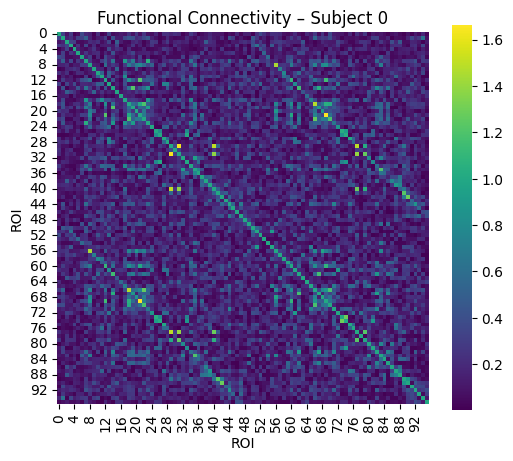

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

out_dir = "/content/drive/MyDrive/Graph Theory Project/Kira Images"

plt.figure(figsize=(6,5))
sns.heatmap(subj0, cmap="viridis", square=True)
plt.title("Functional Connectivity – Subject 0")
plt.xlabel("ROI")
plt.ylabel("ROI")
out_fig = os.path.join(out_dir, "Functional Connectivity.png")
plt.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
meta_df.head()



,subject_id,group,sex
0,fc-002-S-0413,CN,F
1,fc-002-S-1261,CN,F
2,fc-002-S-1280,CN,F
3,fc-002-S-4213-13,CN,F
4,fc-002-S-4262,CN,F


In [ ]:
meta_df.groupby(["group", "sex"]).size()


group  sex
AD     F      10
       M      10
CN     F      10
       M      10
dtype: int64

In [ ]:
#checking to make sure they are the same entries
print("FC subjects:", fc_array.shape[0])
print("Metadata rows:", len(meta_df))


FC subjects: 40
Metadata rows: 40


In [ ]:
#selecting subsects in metadata
fc_AD = fc_array[meta_df.group == "AD"]
fc_CN = fc_array[meta_df.group == "CN"]

print("AD shape:", fc_AD.shape)
print("CN shape:", fc_CN.shape)


AD shape: (20, 96, 96)
CN shape: (20, 96, 96)


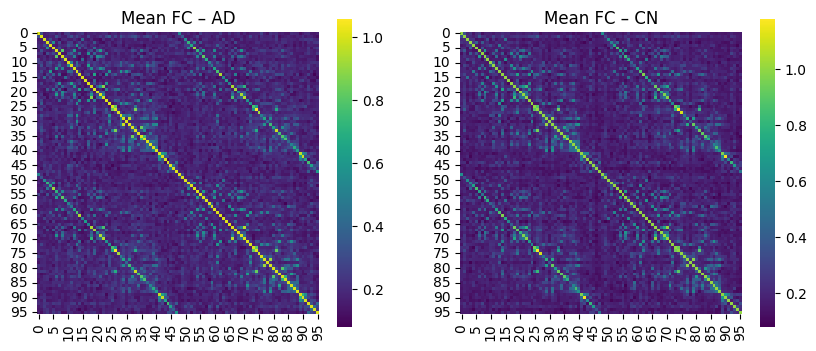

In [ ]:
#visualizing group average for fc
mean_AD = fc_AD.mean(axis=0)
mean_CN = fc_CN.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(mean_AD, ax=axes[0], cmap="viridis", square=True)
axes[0].set_title("Mean FC – AD")

sns.heatmap(mean_CN, ax=axes[1], cmap="viridis", square=True)
axes[1].set_title("Mean FC – CN")

plt.show()


-Mean functional connectivity matrices computed by averaging subject-level FC matrices within each group (AD and CN)

-96 × 96 matrices corresponding to the same RM96 ROI atlas in both groups

-Color intensity represents average connectivity strength between ROI pairs across subjects in each group

-Strong diagonal reflects self-connections (diagonal fixed to 1 prior to averaging)

-Symmetry across the diagonal confirms undirected, correlation-based connectivity in both groups

-Block-like modular structure is visible in both AD and CN, indicating preserved large-scale functional organization

-Subtle differences in off-diagonal intensity patterns suggest group-level alterations in connectivity strength rather than gross reorganization

-Overall similarity in structure indicates that disease effects are likely quantitative (strength/efficiency changes) rather than complete loss of network architecture

figure caption: Group-averaged functional connectivity matrices for Alzheimer’s disease (AD) and cognitively normal (CN) subjects, showing preserved modular structure with subtle differences in average connectivity strength.

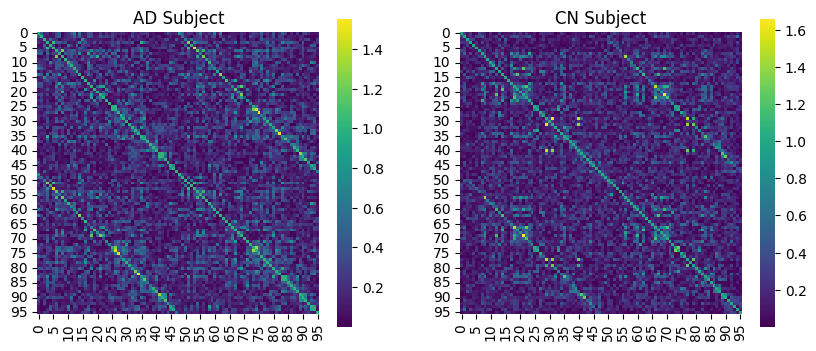

In [ ]:
# Comapring AD vs CN visually
subj_AD = fc_array[meta_df.group == "AD"][0]
subj_CN = fc_array[meta_df.group == "CN"][0]

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(subj_AD, ax=axes[0], cmap="viridis", square=True)
axes[0].set_title("AD Subject")

sns.heatmap(subj_CN, ax=axes[1], cmap="viridis", square=True)
axes[1].set_title("CN Subject")

plt.show()


-Left panel: Functional connectivity matrix for a single Alzheimer’s disease (AD) subject

-Right panel: Functional connectivity matrix for a single cognitively normal (CN) subject

-Each matrix is 96 × 96, corresponding to the same RM96 ROI atlas

-Color intensity represents connectivity strength between pairs of brain regions

-Strong diagonal reflects self-connections (diagonal fixed to 1 prior to visualization)

-Symmetry across the diagonal confirms undirected, correlation-based connectivity

-Both subjects exhibit modular/block-like structure, indicating preserved large-scale functional organization

-Differences appear subtle and localized, suggesting disease effects manifest as changes in connection strength rather than complete loss of network structure

-Single-subject variability is evident, motivating the need for group-level and statistical analyses rather than conclusions from individual subjects

Figure Caption: Example subject-level functional connectivity matrices for an Alzheimer’s disease (AD) subject and a cognitively normal (CN) subject, illustrating symmetric and modular network structure with subject-specific variability.

Single-subject functional connectivity matrices are shown to provide qualitative insight into the structure and variability of individual brain networks and to verify the correctness of data preprocessing and visualization steps. While these examples illustrate preserved symmetry and modular organization in both Alzheimer’s disease and cognitively normal subjects, no conclusions are drawn from individual subjects. Given substantial inter-subject variability in functional connectivity, all inferential analyses in this study are conducted at the group level using aggregated metrics and statistical comparisons.